# Scale-Invariant Feature Transform (SIFT)

In [46]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


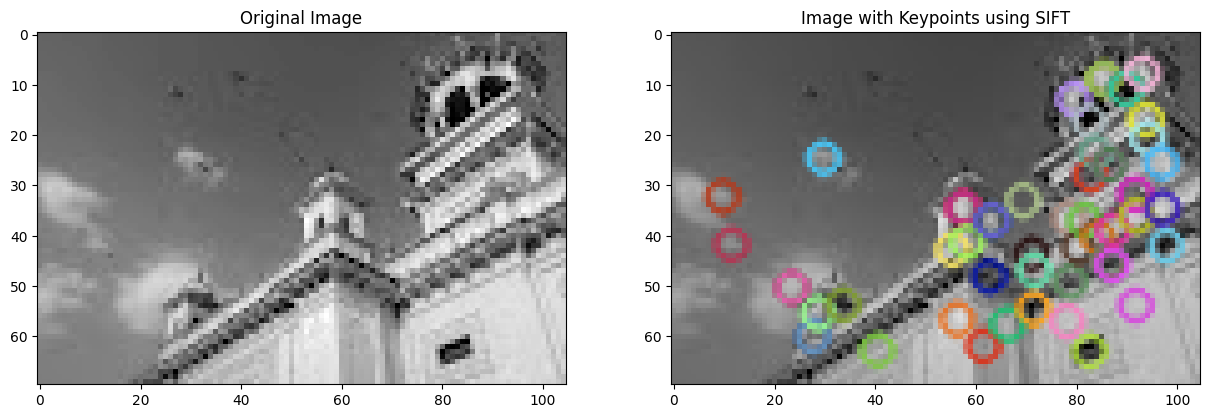

In [47]:
# Reading Input Image
image = cv2.imread('/content/home.jpg', cv2.IMREAD_GRAYSCALE)

# Detecting Keypoints
siftObj = cv2.SIFT_create()
keyPoints, descriptors = siftObj.detectAndCompute(image, None)

# Drawing Keypoints on Input Image
result = cv2.drawKeypoints(image, keyPoints, None)

# Displaying Results
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Original Image')
ax2.imshow(result)
ax2.title.set_text('Image with Keypoints using SIFT')


# image segmentation

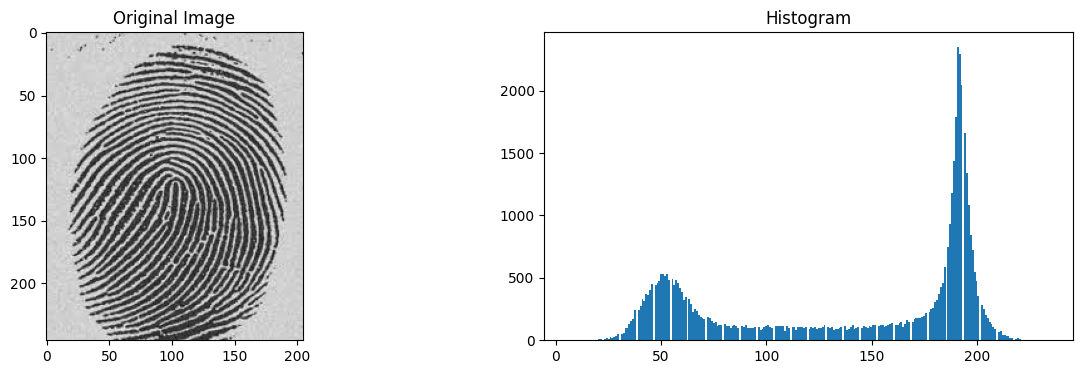

In [48]:
image = cv2.imread('/content/fingerprint.jpg', cv2.IMREAD_GRAYSCALE)
fig = plt.figure(figsize=(15,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Original Image')
ax2.hist(image.ravel(), bins=256)
ax2.title.set_text('Histogram')

In [49]:
import numpy as np
# Initial threshold
T = (np.max(image) + np.min(image)) / 2
T0 = 0.5   # Tolerance
while True:
    print(f"Threshold = {T}")
    # Flatten the image
    flat_image = image.ravel()
    # Divide pixels into two groups
    u1_pixels = flat_image[flat_image > T]
    u2_pixels = flat_image[flat_image <= T]
    # Stop if either group is empty
    if len(u1_pixels) == 0 or len(u2_pixels) == 0:
        break
    # Compute the mean of each group
    m1 = np.mean(u1_pixels)
    m2 = np.mean(u2_pixels)
    # Compute new threshold
    T_new = (m1 + m2) / 2
    # Check for convergence
    if abs(T_new - T) < T0:
        T = T_new
        break
    # Update threshold
    T = T_new
# Apply threshold
global_thres = image > T

Threshold = 120.0
Threshold = 123.80825488637441
Threshold = 124.58247077719997


# Adaptive Thresholding

In [50]:
# Taking Threshold Value as the Mean in the Neighbourhood Area
#adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)
adaptive_thres = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

# Otsu Thresholding

In [51]:
#cv2.threshold(source, thresholdValue, maxVal, thresholdingTechnique)
ret, otsu_thres = cv2.threshold(image, 124, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

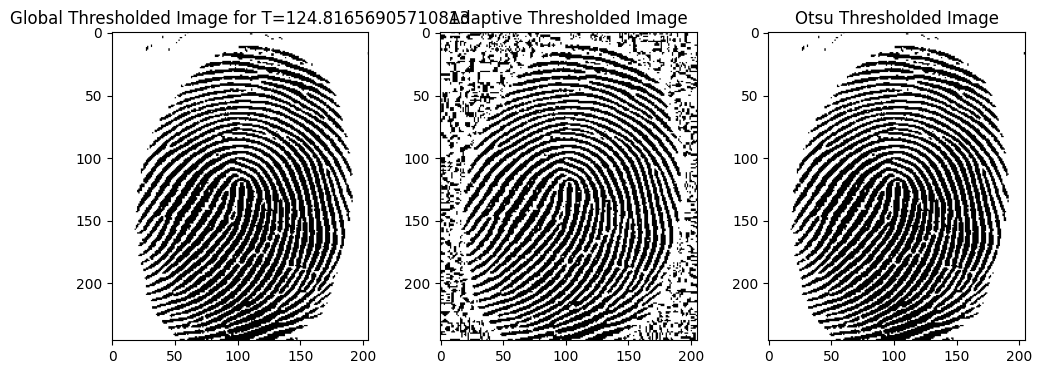

In [52]:
# Displaying Results of Thresholding Techniques
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(global_thres, cmap='gray')
ax1.title.set_text(f'Global Thresholded Image for T={T}')
ax2.imshow(adaptive_thres, cmap='gray')
ax2.title.set_text(f'Adaptive Thresholded Image')
ax3.imshow(otsu_thres, cmap='gray')
ax3.title.set_text(f'Otsu Thresholded Image')

# Edge Detection

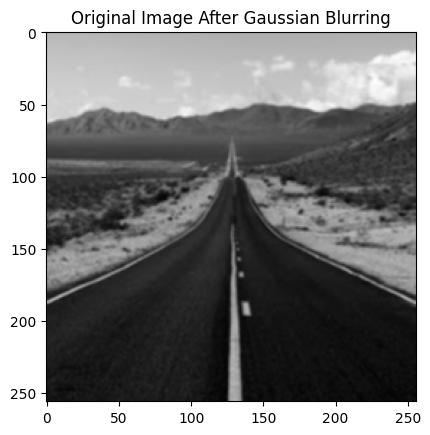

In [53]:
image = cv2.imread('/content/road.jpg', cv2.IMREAD_GRAYSCALE)
image = cv2.GaussianBlur(image, (3,3), 0)
plt.imshow(image, cmap='gray')
plt.title('Original Image After Gaussian Blurring')
plt.show()

# Sobel Edge Detection

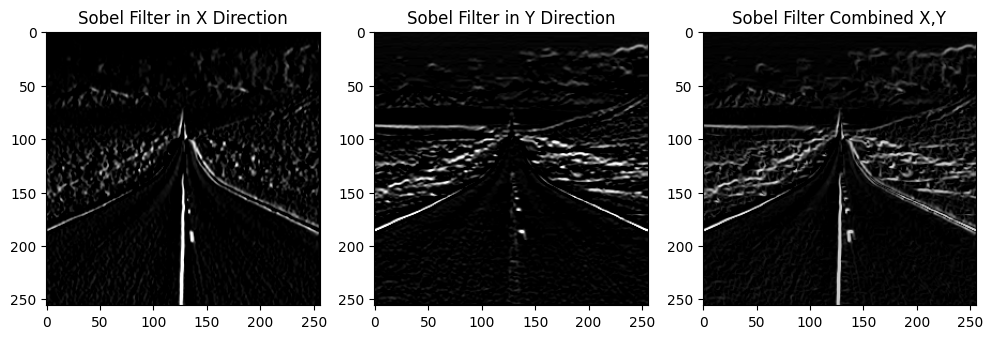

In [54]:
sobelX = cv2.Sobel(image, cv2.CV_8U, 1, 0, ksize=3).astype(np.uint64)
sobelY = cv2.Sobel(image, cv2.CV_8U, 0, 1, ksize=3).astype(np.uint64)
sobel = np.sqrt(np.power(sobelX, 2) + np.power(sobelY, 2)).astype(np.uint64)
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(sobelX, cmap='gray')
ax1.title.set_text('Sobel Filter in X Direction')
ax2.imshow(sobelY, cmap='gray')
ax2.title.set_text('Sobel Filter in Y Direction')
ax3.imshow(sobel, cmap='gray')
ax3.title.set_text('Sobel Filter Combined X,Y')

# Laplacian Edge Detection

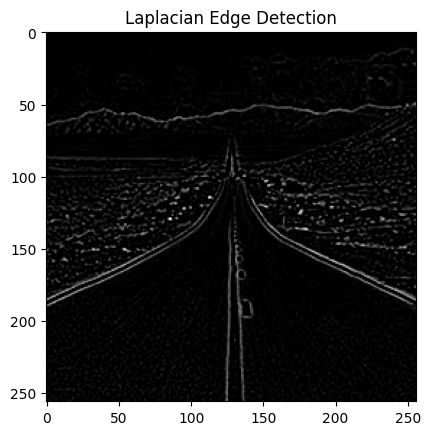

In [55]:
laplacian = cv2.Laplacian(image, cv2.CV_8U)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Edge Detection')
plt.show()

# Canny Edge Detector

Canny Edge Detector

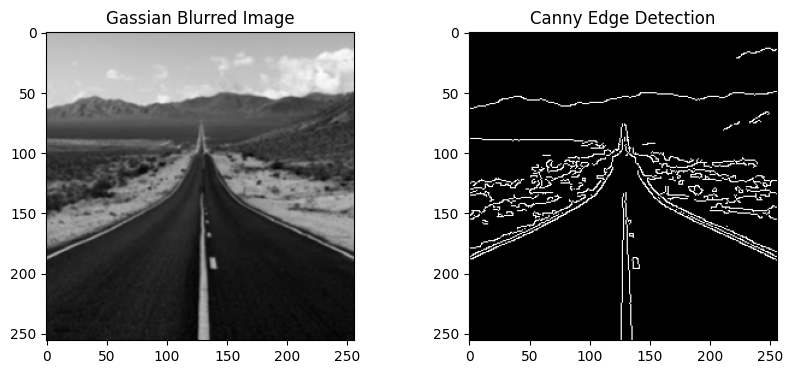

In [56]:
THRESHOLD1 = 100
THRESHOLD2 = 200
canny = cv2.Canny(image, THRESHOLD1, THRESHOLD2)
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Gassian Blurred Image')
ax2.imshow(canny, cmap='gray')
ax2.title.set_text('Canny Edge Detection')

# Hough Line Transformation

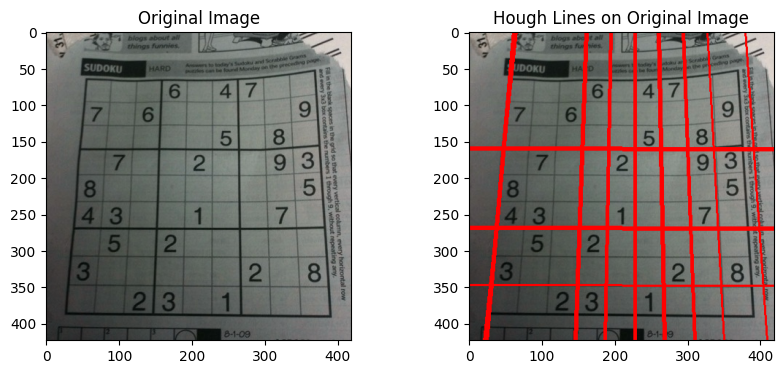

In [57]:
image = cv2.imread('/content/sudoku-original.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)
lines = cv2.HoughLines(edges, 1, np.pi/180, 200)
for rt in lines:
  for rho, theta in rt:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(image, (x1,y1), (x2,y2), (255,0,), 2)

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(cv2.imread('/content/sudoku-original.jpg'))
ax1.title.set_text('Original Image')
ax2.imshow(image)
ax2.title.set_text('Hough Lines on Original Image')

# Isolated Point Detection

In [58]:
# Using Point Detection Mask on Image
image = cv2.imread('/content/turbine.jpg', cv2.IMREAD_GRAYSCALE)
point_detection_mask = np.array([[-1,-1,-1],
[-1,8,-1],
[-1,-1,-1]])
filtered = cv2.filter2D(image, -1, point_detection_mask)

In [59]:
# Thresholding
T = 0.9 * np.max(filtered) # 90% of the highest absolute pixel value of the image filtered
thresh = filtered > T


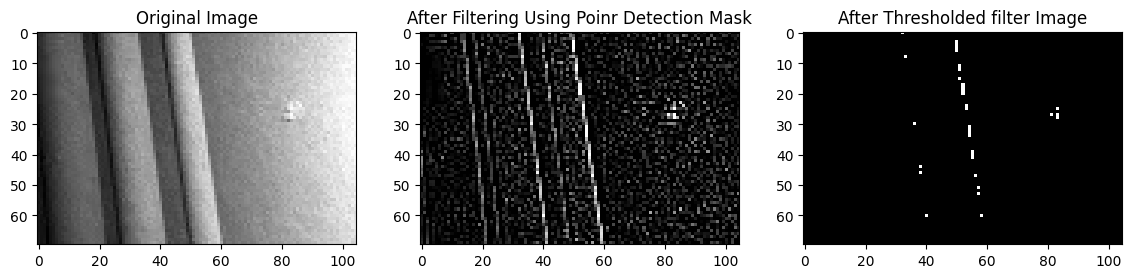

In [60]:
# Display Resuts
fig = plt.figure(figsize=(14, 12))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Original Image')
ax2.imshow(filtered, cmap='gray')
ax2.title.set_text('After Filtering Using Poinr Detection Mask')
ax3.imshow(thresh, cmap='gray')
ax3.title.set_text('After Thresholded filter Image')
plt.show()

